# Contrastive Experiments Analysis



This notebook analyzes the performance of contrastive scoring and explanation experiments using Qwen3-32B. We compare different non-activating sources (random, co-occurrence, faiss, decoder_similarity) and ranking strategies (top vs quantiles) across multiple metrics.



## Analysis Overview



- **Mean Frequency-Weighted F1 Scores**: Bar charts comparing performance across configurations

- **Performance Distribution**: KDE plots showing density distributions of F1 scores

- **Scoring vs Explanation Comparison**: Side-by-side analysis of contrastive scoring and explanation performance



## Configuration Pattern



Experiments follow the pattern: `{model}_{source}_{mode}_{ranking}`

- **Sources**: random (baseline), co-occurrence, faiss, decoder_similarity

- **Modes**: contrastive_scorer_only, baseline

- **Ranking**: top, quantiles

## 1. Setup and Configuration

Import required libraries and set up the analysis environment.

In [ ]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from scipy import stats
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from bootstrap_ci import compute_weighted_ci_errors

# Add the parent directory to the path to import delphi modules
sys.path.append(str(Path.cwd().parent))

from delphi.log.result_analysis import (
    import_plotly,
    load_data,
    get_agg_metrics,
    add_latent_f1,
    compute_confusion,
    compute_classification_metrics,
    frequency_weighted_f1
)

# Import plotly for plotting
px = import_plotly()

# Configuration
SCORING_EXPERIMENT_DIR = "Contrastive Scoring 500 Latents"
EXPLANATION_EXPERIMENT_DIR = "Contrastive Explaining 500 Latents"
SELECTED_MODEL = "Qwen3-32B"  # Focus on this model only
CONFIDENCE_LEVEL = 0.95
ENABLE_BOOTSTRAP = True
BOOTSTRAP_SAMPLES = 1000
N_JOBS = 8  # Number of threads for parallel bootstrap processing

# Set up directories
results_dir = Path.cwd().parent / "results"
visualizations_dir = results_dir / "visualizations" / "contrastive_experiments"
visualizations_dir.mkdir(exist_ok=True, parents=True)

print(f"Scoring experiment directory: {SCORING_EXPERIMENT_DIR}")
print(f"Explanation experiment directory: {EXPLANATION_EXPERIMENT_DIR}")
print(f"Selected model: {SELECTED_MODEL}")
print(f"Results directory: {results_dir}")
print(f"Visualizations output: {visualizations_dir}")

# Define color scheme for different experiment types
SOURCE_COLORS = {
    'random': '#E53E3E',        # Red for baseline
    'co-occurrence': '#3182CE', # Blue
    'faiss': '#38A169',         # Green  
    'decoder_similarity': '#805AD5'  # Purple
}

RANKING_STYLES = {
    'top': 'solid',
    'quantiles': 'dashed'
}

# Clean display name mappings
SOURCE_DISPLAY = {
    'random': 'Random',
    'co-occurrence': 'Co-occurrence',
    'faiss': 'FAISS',
    'decoder_similarity': 'Decoder Sim.'
}

RANKING_DISPLAY = {
    'top': 'Top',
    'quantiles': 'Quantiles'
}

def parse_experiment_name(exp_name):
    """Parse experiment directory name to extract components."""
    # Remove pythiaST_ prefix
    name = exp_name.replace('pythiaST_', '')
    
    # Extract model name (first part before the source)
    # Pattern: Qwen3_14B_quantized_w4a16 or Qwen3_32B_quantized_w4a16
    model = None
    model_display = None
    if 'Qwen3_14B' in name:
        model = 'Qwen3_14B'
        model_display = 'Qwen3-14B'
    elif 'Qwen3_32B' in name:
        model = 'Qwen3_32B'
        model_display = 'Qwen3-32B'
    else:
        # Try to extract the first part as model name
        parts = name.split('_')
        if len(parts) > 1:
            model = '_'.join(parts[:2])  # Take first two parts as model name
            model_display = model
    
    # Find the source (random, co-occurrence, faiss, decoder)
    source = None
    if 'random' in name:
        source = 'random'
    elif 'co-occurrence' in name:
        source = 'co-occurrence'
    elif 'faiss' in name:
        source = 'faiss'
    elif 'decoder' in name:
        source = 'decoder_similarity'
    
    # Find the ranking strategy
    ranking = 'quantiles' if 'quantiles' in name else 'top'
    
    # Determine mode
    mode = 'baseline' if 'baseline' in name else 'contrastive'
    
    # Create clean display name
    source_display = SOURCE_DISPLAY.get(source, source)
    ranking_display = RANKING_DISPLAY.get(ranking, ranking)
    display_name = f"{source_display} ({ranking_display})"
    
    return {
        'model': model,
        'model_display': model_display,
        'source': source,
        'ranking': ranking,
        'mode': mode,
        'display_name': display_name
    }

# Check available experiments
for exp_dir_name in [SCORING_EXPERIMENT_DIR, EXPLANATION_EXPERIMENT_DIR]:
    experiments_base = results_dir / "pythiaST" / exp_dir_name
    if experiments_base.exists():
        print(f"\nAvailable experiments in {exp_dir_name}:")
        model_groups = {}
        for exp_dir in sorted(experiments_base.glob('pythiaST_*')):
            config = parse_experiment_name(exp_dir.name)
            model_name = config['model_display']
            if model_name not in model_groups:
                model_groups[model_name] = []
            model_groups[model_name].append(config['display_name'])
            print(f"  - {exp_dir.name} -> {model_name}: {config['display_name']}")
        
        print(f"\nFound {len(model_groups)} model types:")
        for model_name, experiments in model_groups.items():
            print(f"  {model_name}: {len(experiments)} experiments")
    else:
        print(f"Warning: Experiments directory not found: {experiments_base}")

## 2. Load Contrastive Experiment Results

Load results from all available contrastive experiments and process them for analysis.

In [2]:
def load_contrastive_results(results_dir: Path, experiment_dir: str, selected_model: str = None):
    """Load results from all contrastive experiments, optionally filtering by model."""
    experiment_results = {}
    experiment_stats = {}
    
    experiments_base = results_dir / "pythiaST" / experiment_dir
    
    if not experiments_base.exists():
        print(f"Warning: Experiments directory not found: {experiments_base}")
        return experiment_results, experiment_stats
    
    for exp_dir in experiments_base.glob('pythiaST_*'):
        config = parse_experiment_name(exp_dir.name)
        
        # Filter by selected model if specified
        if selected_model and config['model_display'] != selected_model:
            continue
        
        # Create unique key that includes model name
        unique_key = f"{config['model_display']}: {config['display_name']}"
        
        scores_path = exp_dir / "scores"
        if scores_path.exists():
            try:
                # Use the shared cache from the parent pythiaST directory
                latents_path = results_dir / "pythiaST" / "cache" / "latents"
                if not latents_path.exists():
                    latents_path = exp_dir / "latents"  # Fallback to local latents
                
                if latents_path.exists():
                    # Extract module names from the actual files
                    sample_score_dir = next(scores_path.iterdir())
                    sample_files = list(sample_score_dir.glob("*.txt"))
                    if sample_files:
                        # Extract module name from filename pattern
                        sample_filename = sample_files[0].stem
                        module_name = sample_filename.split('_latent')[0]
                        modules = [module_name]
                    else:
                        print(f"No score files found in {sample_score_dir}")
                        continue
                    
                    # Use load_data from result_analysis.py
                    latent_df, counts = load_data(scores_path, latents_path, modules)
                    
                    if latent_df.empty:
                        print(f"No data found for {unique_key}")
                        continue
                    
                    # Use add_latent_f1 and get_agg_metrics from result_analysis.py
                    latent_df = add_latent_f1(latent_df)
                    processed_df = get_agg_metrics(latent_df, counts)
                    
                    experiment_results[unique_key] = {
                        'latent_df': latent_df,
                        'processed_df': processed_df,
                        'counts': counts,
                        'config': config
                    }
                else:
                    print(f"Latents path not found for {unique_key}")
            
            except Exception as e:
                print(f"Error loading results for {exp_dir.name}: {e}")
                continue
        
        # Load experiment statistics
        stats_file = exp_dir / "explainer_stats.json"
        if stats_file.exists():
            try:
                with open(stats_file, 'r') as f:
                    stats = json.load(f)
                    experiment_stats[unique_key] = stats
            except Exception as e:
                print(f"Error loading stats for {exp_dir.name}: {e}")
                experiment_stats[unique_key] = None
        else:
            experiment_stats[unique_key] = None
    
    return experiment_results, experiment_stats

# Load scoring experiment results
print(f"Loading scoring experiment results for {SELECTED_MODEL}...")
scoring_results, scoring_stats = load_contrastive_results(results_dir, SCORING_EXPERIMENT_DIR, SELECTED_MODEL)

print(f"\nLoaded {len(scoring_results)} scoring experiments:")
for exp_name in scoring_results.keys():
    print(f"  - {exp_name}")

# Load explanation experiment results
print(f"\nLoading explanation experiment results for {SELECTED_MODEL}...")
explanation_results, explanation_stats = load_contrastive_results(results_dir, EXPLANATION_EXPERIMENT_DIR, SELECTED_MODEL)

print(f"\nLoaded {len(explanation_results)} explanation experiments:")
for exp_name in explanation_results.keys():
    print(f"  - {exp_name}")

# Combine both for convenience
all_experiment_results = {**scoring_results, **explanation_results}

# Display sample metrics
if scoring_results:
    sample_exp = list(scoring_results.keys())[0]
    sample_data = scoring_results[sample_exp]['processed_df']
    print(f"\nSample metrics from scoring experiment {sample_exp}:")
    print(sample_data[['score_type', 'accuracy', 'f1_score', 'precision', 'recall', 'weighted_f1']].round(3))

Loading scoring experiment results for Qwen3-32B...

Loaded 8 scoring experiments:
  - Qwen3-32B: Random (Quantiles)
  - Qwen3-32B: Random (Top)
  - Qwen3-32B: Co-occurrence (Quantiles)
  - Qwen3-32B: Co-occurrence (Top)
  - Qwen3-32B: Decoder Sim. (Top)
  - Qwen3-32B: FAISS (Quantiles)
  - Qwen3-32B: FAISS (Top)
  - Qwen3-32B: Decoder Sim. (Quantiles)

Loading explanation experiment results for Qwen3-32B...

Loaded 8 explanation experiments:
  - Qwen3-32B: Random (Quantiles)
  - Qwen3-32B: Random (Top)
  - Qwen3-32B: Co-occurrence (Quantiles)
  - Qwen3-32B: Co-occurrence (Top)
  - Qwen3-32B: Decoder Sim. (Quantiles)
  - Qwen3-32B: Decoder Sim. (Top)
  - Qwen3-32B: FAISS (Quantiles)
  - Qwen3-32B: FAISS (Top)

Sample metrics from scoring experiment Qwen3-32B: Random (Quantiles):
  score_type  accuracy  f1_score  precision  recall  weighted_f1
0  detection     0.795     0.698      0.617   0.804        0.558
1       fuzz     0.889     0.834      0.798   0.873        0.674


## 3. Generate Mean Frequency-Weighted F1 Bar Charts

Create bar charts showing mean frequency-weighted F1 scores across all contrastive experiments, organized by source and ranking strategy.

In [ ]:
# Bootstrap CI computation is now imported from bootstrap_ci module

def compute_mean_f1_across_score_types(
    experiment_results,
    score_types=['detection', 'fuzz'],
    enable_bootstrap=ENABLE_BOOTSTRAP,
    n_boot=BOOTSTRAP_SAMPLES,
    confidence=CONFIDENCE_LEVEL,
    n_jobs=N_JOBS,
):
    """Compute mean frequency-weighted F1 and unweighted mean F1 across score types with CI errors."""
    rows = []

    for exp_name, data in tqdm(experiment_results.items(), desc="Computing mean F1 with bootstrap CIs"):
        processed_df = data['processed_df']
        latent_df = data['latent_df']
        counts = data['counts']
        config = data['config']

        freq_weighted_scores = []
        mean_f1_scores = []
        lower_errors = []
        upper_errors = []

        for score_type in score_types:
            score_row = processed_df[processed_df['score_type'] == score_type]
            if len(score_row) == 0:
                continue

            if 'weighted_f1' in score_row.columns:
                freq_weighted_f1 = score_row['weighted_f1'].iloc[0]
                if freq_weighted_f1 is not None:
                    freq_weighted_scores.append(float(freq_weighted_f1))

                    if enable_bootstrap and counts is not None:
                        score_subset = latent_df[latent_df['score_type'] == score_type]
                        if len(score_subset) > 0:
                            try:
                                lower_err, upper_err = compute_weighted_ci_errors(
                                    score_subset,
                                    counts,
                                    freq_weighted_f1,
                                    confidence,
                                    n_boot,
                                    n_jobs,
                                    use_cache=True,
                                )
                                lower_errors.append(lower_err)
                                upper_errors.append(upper_err)
                            except Exception as e:
                                print(f"Warning: Bootstrap CI failed for {exp_name} {score_type}: {e}")
                                lower_errors.append(0.0)
                                upper_errors.append(0.0)
                        else:
                            lower_errors.append(0.0)
                            upper_errors.append(0.0)
                    else:
                        lower_errors.append(0.0)
                        upper_errors.append(0.0)

            if 'f1_score' in score_row.columns:
                mean_f1_value = score_row['f1_score'].iloc[0]
                if mean_f1_value is not None:
                    mean_f1_scores.append(float(mean_f1_value))

        if len(freq_weighted_scores) == 0 and len(mean_f1_scores) == 0:
            rows.append({
                'experiment': config['display_name'],
                'model': config['model_display'],
                'source': config['source'],
                'ranking': config['ranking'],
                'mode': config['mode'],
                'frequency_weighted_f1': None,
                'mean_f1': None,
                'ci_lower_error': 0.0,
                'ci_upper_error': 0.0,
                'n_score_types': 0,
            })
            continue

        mean_weighted_f1 = float(np.mean(freq_weighted_scores)) if len(freq_weighted_scores) > 0 else None
        mean_unweighted_f1 = float(np.mean(mean_f1_scores)) if len(mean_f1_scores) > 0 else None

        if len(lower_errors) > 0:
            mean_lower_error = float(np.mean(lower_errors))
            mean_upper_error = float(np.mean(upper_errors))
        else:
            mean_lower_error = 0.0
            mean_upper_error = 0.0

        rows.append({
            'experiment': config['display_name'],
            'model': config['model_display'],
            'source': config['source'],
            'ranking': config['ranking'],
            'mode': config['mode'],
            'frequency_weighted_f1': mean_weighted_f1,
            'mean_f1': mean_unweighted_f1,
            'ci_lower_error': mean_lower_error,
            'ci_upper_error': mean_upper_error,
            'n_score_types': max(len(freq_weighted_scores), len(mean_f1_scores)),
        })

    return pd.DataFrame(rows)

# Compute mean F1 for scoring experiments
print(f"Computing mean F1 for scoring experiments (bootstrap={ENABLE_BOOTSTRAP})")
scoring_f1_table = compute_mean_f1_across_score_types(scoring_results, score_types=['detection', 'fuzz'])

# Compute mean F1 for explanation experiments
print(f"Computing mean F1 for explanation experiments (bootstrap={ENABLE_BOOTSTRAP})")
explanation_f1_table = compute_mean_f1_across_score_types(explanation_results, score_types=['detection', 'fuzz'])

# Helper to calculate random baseline F1 from class distribution

def calculate_random_baseline_f1(experiment_results):
    if not experiment_results:
        return 0.5

    first_exp = list(experiment_results.values())[0]
    latent_df = first_exp['latent_df']

    if latent_df.empty:
        return 0.5

    baseline_f1s = []
    for score_type in ['detection', 'fuzz']:
        score_subset = latent_df[latent_df['score_type'] == score_type]
        if len(score_subset) == 0:
            continue
        total_positives = score_subset['activating'].sum()
        total_examples = len(score_subset)
        p = total_positives / total_examples if total_examples > 0 else 0.5
        random_f1 = p / (p + 0.5) if (p + 0.5) > 0 else 0
        baseline_f1s.append(random_f1)

    return float(np.mean(baseline_f1s)) if baseline_f1s else 0.5

random_baseline_f1 = calculate_random_baseline_f1(scoring_results)

# Create bar chart utility

def plot_bar_chart(model_df, value_column, title_suffix, filename_suffix):
    if model_df.empty or model_df[value_column].notna().sum() == 0:
        print(f"No data available for {title_suffix} bar chart")
        return

    sorted_df = model_df.sort_values(value_column, ascending=False)

    fig = px.bar(
        sorted_df,
        x='experiment',
        y=value_column,
        color='source',
        color_discrete_map=SOURCE_COLORS,
        title=f'{SELECTED_MODEL} - {title_suffix} ({int(CONFIDENCE_LEVEL*100)}% CI)',
        text=value_column,
        hover_data=['ranking', 'mode', 'n_score_types']
    )

    fig.update_traces(
        error_y=dict(
            type='data',
            symmetric=False,
            array=sorted_df['ci_upper_error'],
            arrayminus=sorted_df['ci_lower_error']
        )
    )

    fig.add_hline(
        y=random_baseline_f1,
        line_dash="dot",
        line_color="red",
        line_width=2,
        annotation_text=f"Random Baseline (F1={random_baseline_f1:.3f})",
        annotation_position="right"
    )

    y_min = min(0, random_baseline_f1 - 0.1)
    y_max = max(1, sorted_df[value_column].dropna().max() + 0.1)

    fig.update_layout(
        yaxis_range=[y_min, y_max],
        xaxis_title="Experiment Configuration",
        yaxis_title=f"{value_column.replace('_', ' ').title()} ({int(CONFIDENCE_LEVEL*100)}% CI)",
        xaxis={'tickangle': 45},
        height=600,
        legend_title="Non-Activating Source"
    )

    fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig.show()

    safe_model = SELECTED_MODEL.replace('-', '').replace(' ', '_')
    output_file_pdf = visualizations_dir / f"contrastive_{filename_suffix}_{safe_model}.pdf"
    output_file_png = visualizations_dir / f"contrastive_{filename_suffix}_{safe_model}.png"
    fig.write_image(str(output_file_pdf))
    fig.write_image(str(output_file_png))
    print(f"Saved bar chart: {output_file_pdf}")

# Plot frequency-weighted and unweighted mean F1 for scoring experiments
print("\nGenerating scoring bar charts...")
plot_bar_chart(
    scoring_f1_table.copy(),
    value_column='frequency_weighted_f1',
    title_suffix='Contrastive Scoring - Mean Frequency-Weighted F1 (Detection + Fuzz)',
    filename_suffix='scoring_freq_weighted_f1_bar_mean'
)
plot_bar_chart(
    scoring_f1_table.copy(),
    value_column='mean_f1',
    title_suffix='Contrastive Scoring - Mean F1 (Detection + Fuzz)',
    filename_suffix='scoring_mean_f1_bar_mean'
)

# Plot frequency-weighted and unweighted mean F1 for explanation experiments
print("\nGenerating explanation bar charts...")
plot_bar_chart(
    explanation_f1_table.copy(),
    value_column='frequency_weighted_f1',
    title_suffix='Contrastive Explanation - Mean Frequency-Weighted F1 (Detection + Fuzz)',
    filename_suffix='explanation_freq_weighted_f1_bar_mean'
)
plot_bar_chart(
    explanation_f1_table.copy(),
    value_column='mean_f1',
    title_suffix='Contrastive Explanation - Mean F1 (Detection + Fuzz)',
    filename_suffix='explanation_mean_f1_bar_mean'
)

print(f"\nBar charts saved to {visualizations_dir}")

Computing mean F1 for scoring experiments (bootstrap=True)


Computing mean F1 with bootstrap CIs:   0%|          | 0/8 [00:00<?, ?it/s]

  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95

Computing mean F1 with bootstrap CIs:   0%|          | 0/8 [00:00<?, ?it/s]

  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_detection_375latents_1000samples_conf95]
  [Using cached bootstrap results: bootstrap_fuzz_375latents_1000samples_conf95

/tmp/ipykernel_1930726/1625428978.py:171: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/tmp/ipykernel_1930726/1625428978.py:172: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




Saved contrastive scoring F1 bar chart: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_scoring_freq_weighted_f1_bar_Qwen332B_mean.pdf


Saved contrastive explanation F1 bar chart: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_explanation_freq_weighted_f1_bar_Qwen332B_mean.pdf

Bar charts saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


/tmp/ipykernel_1930726/1625428978.py:251: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/tmp/ipykernel_1930726/1625428978.py:252: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




### 3.1 Scoring vs Explanation Comparison

Create a combined bar chart comparing contrastive scoring and explanation performance across different non-activating sources.


Generating scoring vs explanation comparison chart (quantiles only)...


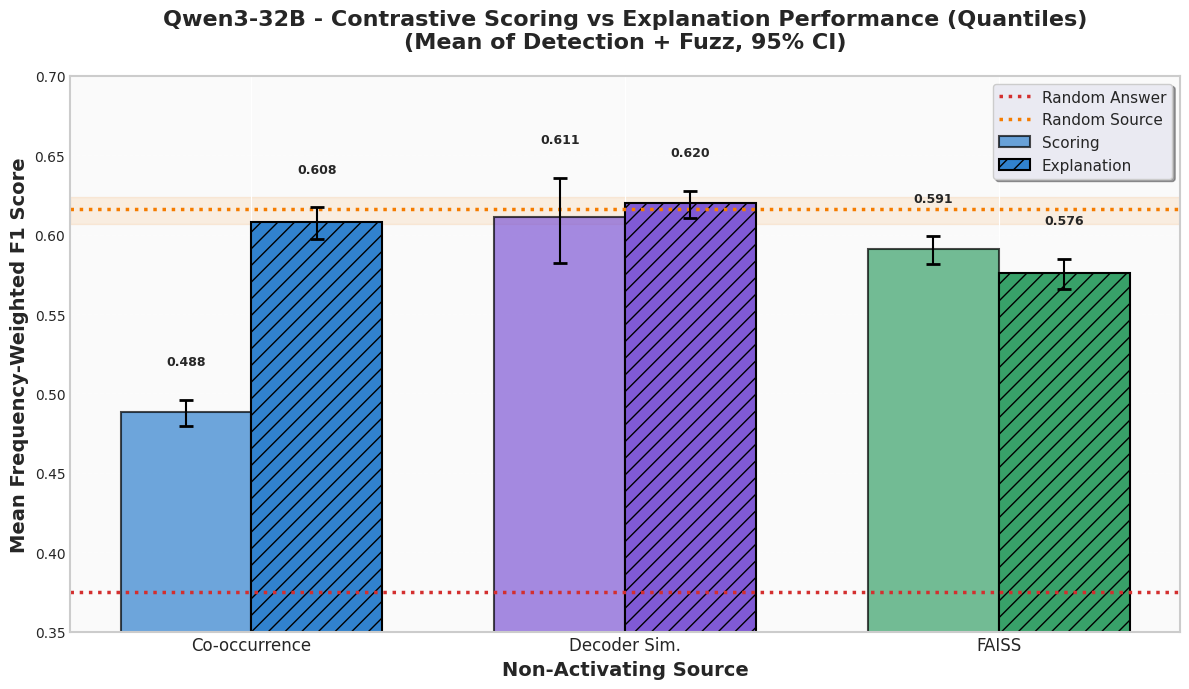

Saved comparison chart: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/scoring_vs_explanation_comparison_Qwen332B.pdf

Comparison chart saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


In [ ]:
# Reusable scoring vs explanation comparison (quantiles only)
def create_scoring_vs_explanation_comparison(scoring_f1_table, explanation_f1_table,
                                            f1_column='frequency_weighted_f1',
                                            y_label='Mean Frequency-Weighted F1 Score',
                                            title_suffix='Mean of Detection + Fuzz',
                                            filename_suffix='weighted',
                                            scoring_results=None):
    """Plot grouped bars comparing scoring vs explanation experiments."""
    print(f"Generating scoring vs explanation comparison chart (quantiles only) - {filename_suffix}...")

    if (scoring_f1_table is None or scoring_f1_table.empty) and (explanation_f1_table is None or explanation_f1_table.empty):
        print("No data available for comparison chart")
        return

    scoring_df = scoring_f1_table.copy() if scoring_f1_table is not None else pd.DataFrame()
    if not scoring_df.empty:
        scoring_df['experiment_type'] = 'Scoring'
    explanation_df = explanation_f1_table.copy() if explanation_f1_table is not None else pd.DataFrame()
    if not explanation_df.empty:
        explanation_df['experiment_type'] = 'Explanation'
    combined_df = pd.concat([scoring_df, explanation_df], ignore_index=True, sort=False)
    combined_df = combined_df.dropna(subset=['source'])
    combined_df = combined_df[combined_df['ranking'] == 'quantiles']

    if combined_df.empty:
        print("No combined data available for quantiles")
        return

    if scoring_results:
        first_exp = list(scoring_results.values())[0]
        baseline_f1s = []
        for score_type in ['detection', 'fuzz']:
            score_subset = first_exp['latent_df'][first_exp['latent_df']['score_type'] == score_type]
            if len(score_subset) > 0:
                total_positives = score_subset['activating'].sum()
                total_examples = len(score_subset)
                p = total_positives / total_examples if total_examples > 0 else 0.5
                random_f1 = p / (p + 0.5) if (p + 0.5) > 0 else 0
                baseline_f1s.append(random_f1)
        random_baseline_f1 = np.mean(baseline_f1s) if len(baseline_f1s) > 0 else 0.5
    else:
        random_baseline_f1 = 0.5

    sources = sorted([s for s in combined_df['source'].unique() if s != 'random'])
    random_df = combined_df[combined_df['source'] == 'random']
    random_examples_value = None
    random_examples_lower = 0
    random_examples_upper = 0
    if len(random_df) > 0 and f1_column in random_df.columns:
        row = random_df.iloc[0]
        random_examples_value = row.get(f1_column, None)
        random_examples_lower = row.get('ci_lower_error', 0)
        random_examples_upper = row.get('ci_upper_error', 0)

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    x_pos = 0
    x_positions = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 1.0

    for source in sources:
        source_data = combined_df[(combined_df['source'] == source) & combined_df[f1_column].notna()]
        if len(source_data) == 0:
            continue
        scoring_data = source_data[source_data['experiment_type'] == 'Scoring']
        explanation_data = source_data[source_data['experiment_type'] == 'Explanation']

        if len(scoring_data) > 0:
            row = scoring_data.iloc[0]
            val = row.get(f1_column, np.nan)
            lower = row.get('ci_lower_error', 0)
            upper = row.get('ci_upper_error', 0)
            ax.bar(
                x_pos,
                val,
                bar_width,
                label='Scoring' if source == sources[0] else '',
                color=SOURCE_COLORS.get(source, '#808080'),
                alpha=0.7,
                edgecolor='black',
                linewidth=1.5,
            )
            ax.errorbar(x_pos, val, yerr=[[lower], [upper]], fmt='none', color='black', capsize=5, capthick=2)
            ax.text(x_pos, val + upper + 0.02, f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

        if len(explanation_data) > 0:
            row = explanation_data.iloc[0]
            val = row.get(f1_column, np.nan)
            lower = row.get('ci_lower_error', 0)
            upper = row.get('ci_upper_error', 0)
            ax.bar(
                x_pos + bar_width,
                val,
                bar_width,
                label='Explanation' if source == sources[0] else '',
                color=SOURCE_COLORS.get(source, '#808080'),
                alpha=1.0,
                edgecolor='black',
                linewidth=1.5,
                hatch='//'
            )
            ax.errorbar(x_pos + bar_width, val, yerr=[[lower], [upper]], fmt='none', color='black', capsize=5, capthick=2)
            ax.text(x_pos + bar_width, val + upper + 0.02, f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

        x_positions.append(x_pos + bar_width / 2)
        x_labels.append(SOURCE_DISPLAY.get(source, source))
        x_pos += group_spacing

    ax.axhline(y=random_baseline_f1, color='#D32F2F', linestyle=':', linewidth=2.5, label='Random Answer', zorder=1)
    if random_examples_value is not None:
        ax.axhline(y=random_examples_value, color='#F57C00', linestyle=':', linewidth=2.5, label='Random Source', zorder=1)
        ax.axhspan(
            random_examples_value - random_examples_lower,
            random_examples_value + random_examples_upper,
            color='#F57C00',
            alpha=0.1,
            zorder=0,
        )

    ax.set_xlabel('Non-Activating Source', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    ax.set_title(
        f'{SELECTED_MODEL} - Contrastive Scoring vs Explanation Performance (Quantiles)\n({title_suffix}, {int(CONFIDENCE_LEVEL*100)}% CI)',
        fontsize=16,
        fontweight='bold',
        pad=20,
    )
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12, fontweight='medium')
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_ylim(0.35, 0.7)
    ax.set_facecolor('#FAFAFA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

    model_safe = SELECTED_MODEL.replace('-', '').replace(' ', '_')
    output_file_pdf = visualizations_dir / f"scoring_vs_explanation_comparison_{filename_suffix}_{model_safe}.pdf"
    output_file_png = visualizations_dir / f"scoring_vs_explanation_comparison_{filename_suffix}_{model_safe}.png"
    plt.savefig(str(output_file_pdf), dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(str(output_file_png), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved comparison chart: {output_file_pdf}")
    plt.close()

create_scoring_vs_explanation_comparison(
    scoring_f1_table,
    explanation_f1_table,
    f1_column='frequency_weighted_f1',
    y_label='Mean Frequency-Weighted F1 Score',
    title_suffix='Mean of Detection + Fuzz',
    filename_suffix='weighted',
    scoring_results=scoring_results,
)

create_scoring_vs_explanation_comparison(
    scoring_f1_table,
    explanation_f1_table,
    f1_column='mean_f1',
    y_label='Mean F1 Score',
    title_suffix='Mean F1 of Detection + Fuzz',
    filename_suffix='mean_f1',
    scoring_results=scoring_results,
)

print(f"\nComparison charts saved to {visualizations_dir}")

## 4. Generate KDE Distribution Plots

Create kernel density estimation plots showing the distribution of F1 scores across different experimental configurations.

Generating KDE plots for mean F1 (detection + fuzz) - Scoring experiments...


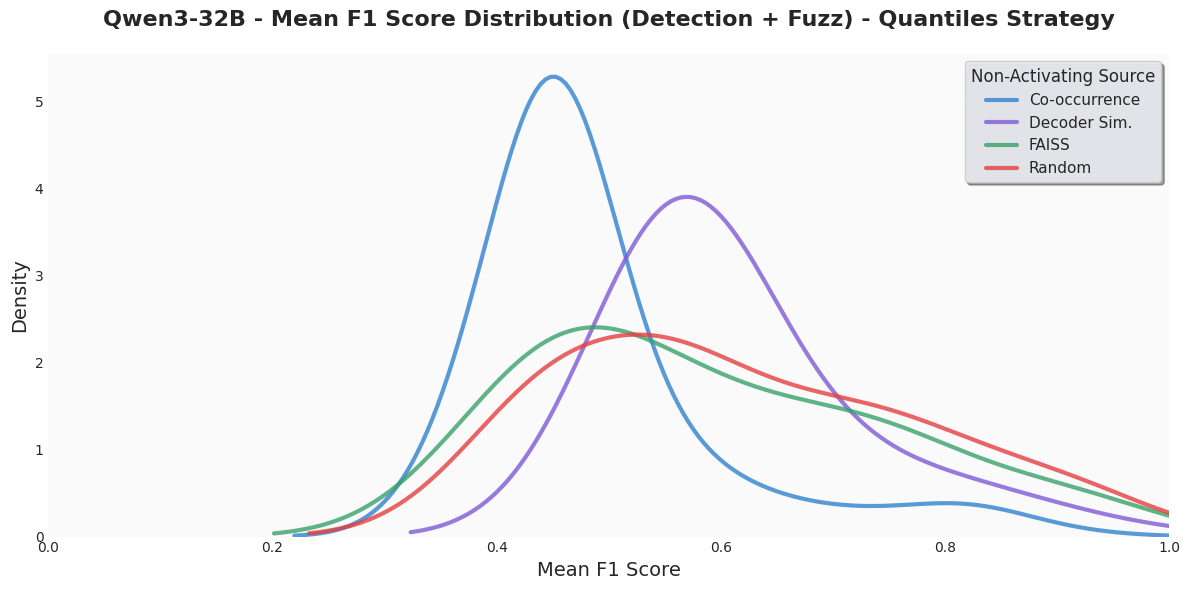

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_mean_quantiles_Qwen332B.pdf


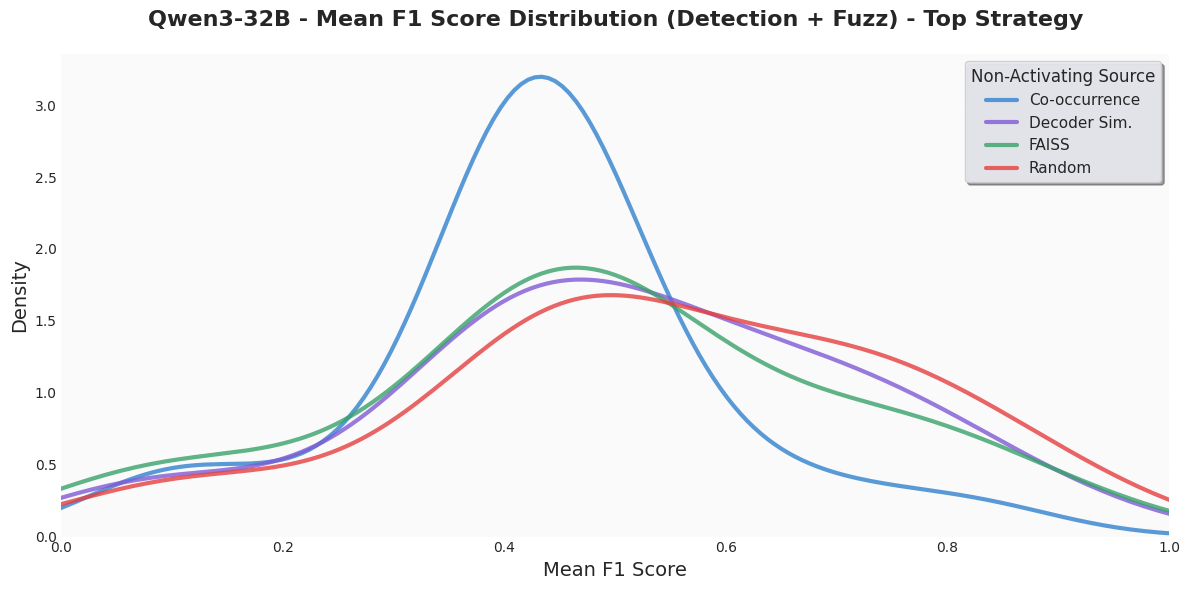

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_mean_top_Qwen332B.pdf

KDE plots saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


In [5]:
def prepare_kde_data_mean(experiment_results, score_types=['detection', 'fuzz']):
    """Prepare data for KDE plots by extracting per-latent mean F1 scores across score types."""
    kde_data = []
    
    for exp_name, data in experiment_results.items():
        latent_df = data['latent_df']
        counts = data['counts']
        config = data['config']
        
        if counts is None:
            continue
        
        # Collect F1 scores for each latent across score types
        latent_f1_map = {}  # (module, latent_idx) -> list of f1 scores
        
        for score_type in score_types:
            score_subset = latent_df[latent_df['score_type'] == score_type]
            
            if len(score_subset) == 0:
                continue
            
            # Extract per-latent F1 scores for this score type
            for (module, latent_idx), grp in score_subset.groupby(["module", "latent_idx"]):
                if module in counts and latent_idx < len(counts[module]):
                    f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
                    firing_count = counts[module][latent_idx].item()
                    
                    if (module, latent_idx) not in latent_f1_map:
                        latent_f1_map[(module, latent_idx)] = {
                            'f1_scores': [],
                            'firing_count': firing_count
                        }
                    latent_f1_map[(module, latent_idx)]['f1_scores'].append(float(f1))
        
        # Compute mean F1 for each latent
        for (module, latent_idx), info in latent_f1_map.items():
            if len(info['f1_scores']) > 0:
                mean_f1 = np.mean(info['f1_scores'])
                kde_data.append({
                    'experiment': exp_name,
                    'source': config['source'],
                    'ranking': config['ranking'],
                    'mode': config['mode'],
                    'f1_score': mean_f1,
                    'firing_count': info['firing_count'],
                    'module': module,
                    'latent_idx': latent_idx,
                    'n_score_types': len(info['f1_scores'])
                })
    
    return pd.DataFrame(kde_data)

# Set up matplotlib style for KDE plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate KDE plots using mean of detection and fuzz for scoring experiments
print(f"Generating KDE plots for mean F1 (detection + fuzz) - Scoring experiments...")

kde_data = prepare_kde_data_mean(scoring_results, score_types=['detection', 'fuzz'])

if kde_data.empty:
    print(f"No data available for mean F1 KDE plot")
else:
    # Create separate plots for each ranking strategy
    ranking_strategies = ['quantiles', 'top']
    
    for ranking_strategy in ranking_strategies:
        ranking_data = kde_data[kde_data['ranking'] == ranking_strategy]
        
        if ranking_data.empty:
            print(f"No data for {ranking_strategy} strategy in mean F1")
            continue
        
        # Create figure comparing all sources for this ranking strategy
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        sources = sorted(ranking_data['source'].unique())
        
        for source in sources:
            source_data = ranking_data[ranking_data['source'] == source]
            
            if len(source_data) > 0:
                # Weight by firing count for the KDE
                weights = source_data['firing_count'].values
                weights = weights / weights.sum()  # Normalize weights
                
                # Create KDE plot with clean labels
                source_label = SOURCE_DISPLAY.get(source, source)
                sns.kdeplot(
                    data=source_data,
                    x='f1_score',
                    weights=weights,
                    ax=ax,
                    label=source_label,
                    color=SOURCE_COLORS.get(source, '#808080'),
                    linewidth=3,
                    alpha=0.8
                )
        
        # Styling
        ranking_display = RANKING_DISPLAY.get(ranking_strategy, ranking_strategy)
        ax.set_title(f'{SELECTED_MODEL} - Mean F1 Score Distribution (Detection + Fuzz) - {ranking_display} Strategy', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Mean F1 Score', fontsize=14, fontweight='medium')
        ax.set_ylabel('Density', fontsize=14, fontweight='medium')
        ax.legend(title='Non-Activating Source', title_fontsize=12, fontsize=11, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        
        # Add subtle background styling
        ax.set_facecolor('#FAFAFA')
        
        plt.tight_layout()
        
        # Show the plot
        plt.show()
        
        # Save the plot
        model_safe = SELECTED_MODEL.replace('-', '').replace(' ', '_')
        output_file_pdf = visualizations_dir / f"contrastive_kde_mean_{ranking_strategy}_{model_safe}.pdf"
        output_file_png = visualizations_dir / f"contrastive_kde_mean_{ranking_strategy}_{model_safe}.png"
        plt.savefig(str(output_file_pdf), dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(str(output_file_png), dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved KDE plot: {output_file_pdf}")
        
        plt.close()

print(f"\nKDE plots saved to {visualizations_dir}")

## 5. Random vs Co-occurrence Per-Latent Comparison

Analyze the performance drop from random to co-occurrence at the per-latent level to see if some latents are more affected than others.

Generating random vs co-occurrence scatter plot (per-latent mean F1)...
Comparing:
  Random: Qwen3-32B: Random (Top)
  Co-occurrence: Qwen3-32B: Co-occurrence (Top)

Per-latent comparison statistics:
  Number of latents: 375
  Mean F1 drop: 0.1207
  Median F1 drop: 0.1026
  Std F1 drop: 0.0961
  Min F1 drop: -0.2762
  Max F1 drop: 0.3909


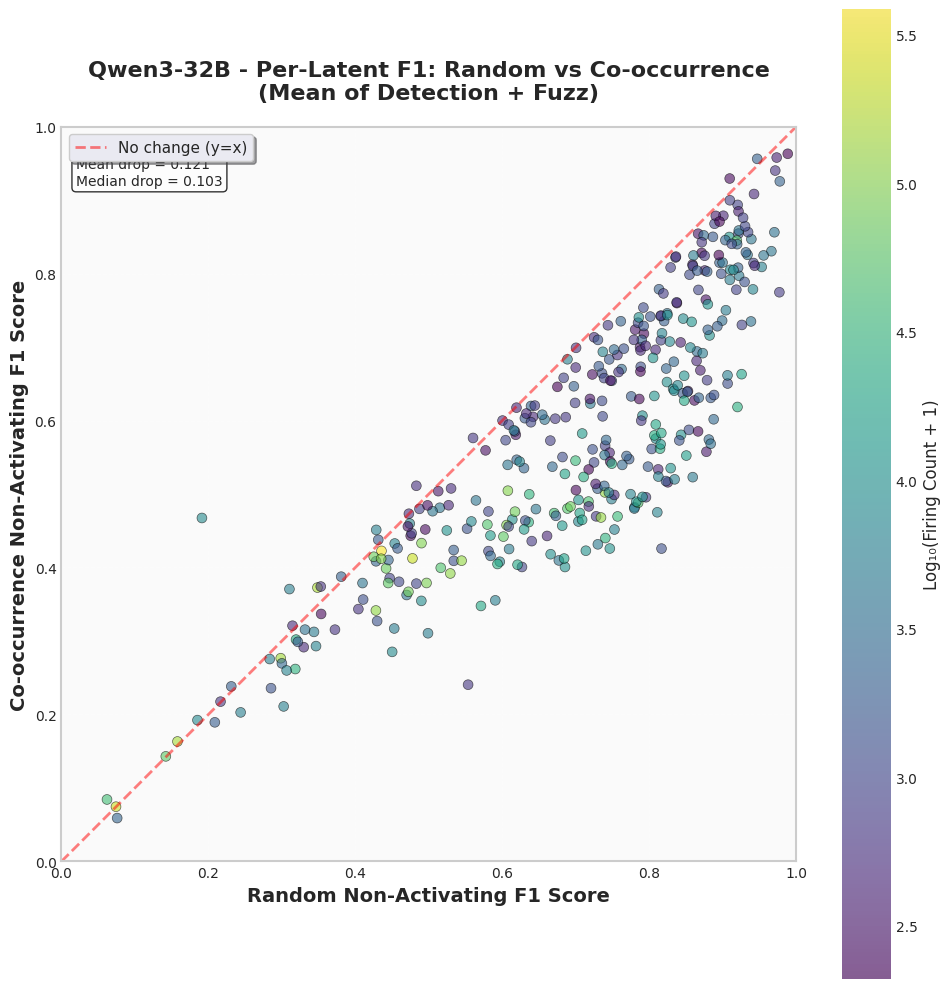


Saved scatter plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/random_vs_cooccurrence_scatter_Qwen332B.pdf


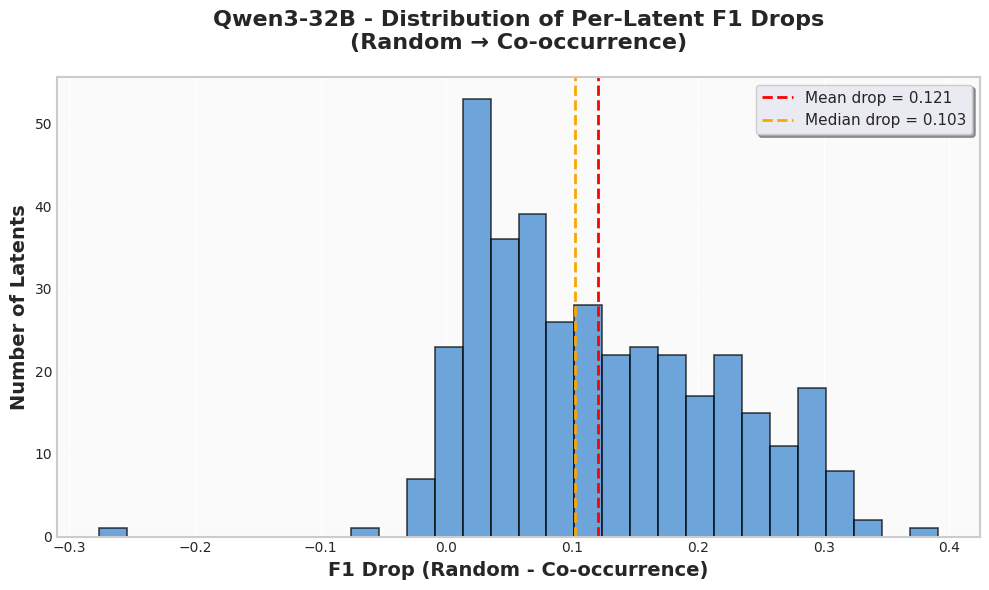

Saved histogram: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/f1_drop_histogram_Qwen332B.pdf

Scatter plot analysis saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


In [6]:
def prepare_random_vs_cooccurrence_scatter(experiment_results, score_types=['detection', 'fuzz']):
    """Prepare per-latent data comparing random vs co-occurrence mean F1 scores across score types.
    
    Returns a DataFrame with one row per latent, containing:
    - random_f1: mean F1 for random non-activating examples
    - cooccurrence_f1: mean F1 for co-occurrence non-activating examples
    - firing_count: frequency of latent activation
    - f1_drop: difference in F1 (random - co-occurrence)
    """
    comparison_data = []
    
    # Find random and co-occurrence experiments (using first available ranking strategy)
    random_exp = None
    cooccurrence_exp = None
    
    for exp_name, data in experiment_results.items():
        config = data['config']
        if config['source'] == 'random':
            random_exp = exp_name
        elif config['source'] == 'co-occurrence':
            cooccurrence_exp = exp_name
    
    if not random_exp or not cooccurrence_exp:
        print(f"Could not find both random and co-occurrence experiments")
        return pd.DataFrame()
    
    print(f"Comparing:\n  Random: {random_exp}\n  Co-occurrence: {cooccurrence_exp}")
    
    random_data = experiment_results[random_exp]
    cooccur_data = experiment_results[cooccurrence_exp]
    
    random_latent_df = random_data['latent_df']
    cooccur_latent_df = cooccur_data['latent_df']
    counts = random_data['counts']
    
    if counts is None:
        print("No counts available")
        return pd.DataFrame()
    
    # Compute per-latent mean F1 across score types for both random and co-occurrence
    random_latent_f1_map = {}  # (module, latent_idx) -> list of f1 scores
    cooccur_latent_f1_map = {}  # (module, latent_idx) -> list of f1 scores
    
    # Process random experiments
    for score_type in score_types:
        random_subset = random_latent_df[random_latent_df['score_type'] == score_type]
        
        for (module, latent_idx), grp in random_subset.groupby(["module", "latent_idx"]):
            if module in counts and latent_idx < len(counts[module]):
                f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
                firing_count = counts[module][latent_idx].item()
                
                if (module, latent_idx) not in random_latent_f1_map:
                    random_latent_f1_map[(module, latent_idx)] = {
                        'f1_scores': [],
                        'firing_count': firing_count
                    }
                random_latent_f1_map[(module, latent_idx)]['f1_scores'].append(float(f1))
    
    # Process co-occurrence experiments
    for score_type in score_types:
        cooccur_subset = cooccur_latent_df[cooccur_latent_df['score_type'] == score_type]
        
        for (module, latent_idx), grp in cooccur_subset.groupby(["module", "latent_idx"]):
            if module in counts and latent_idx < len(counts[module]):
                f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
                firing_count = counts[module][latent_idx].item()
                
                if (module, latent_idx) not in cooccur_latent_f1_map:
                    cooccur_latent_f1_map[(module, latent_idx)] = {
                        'f1_scores': [],
                        'firing_count': firing_count
                    }
                cooccur_latent_f1_map[(module, latent_idx)]['f1_scores'].append(float(f1))
    
    # Match up latents that appear in both experiments
    common_latents = set(random_latent_f1_map.keys()) & set(cooccur_latent_f1_map.keys())
    
    for latent_key in common_latents:
        random_info = random_latent_f1_map[latent_key]
        cooccur_info = cooccur_latent_f1_map[latent_key]
        
        if len(random_info['f1_scores']) > 0 and len(cooccur_info['f1_scores']) > 0:
            random_mean_f1 = np.mean(random_info['f1_scores'])
            cooccur_mean_f1 = np.mean(cooccur_info['f1_scores'])
            
            comparison_data.append({
                'module': latent_key[0],
                'latent_idx': latent_key[1],
                'random_f1': random_mean_f1,
                'cooccurrence_f1': cooccur_mean_f1,
                'f1_drop': random_mean_f1 - cooccur_mean_f1,
                'firing_count': random_info['firing_count'],
                'n_score_types': len(random_info['f1_scores'])
            })
    
    return pd.DataFrame(comparison_data)

# Generate scatter plot data for scoring experiments
print(f"Generating random vs co-occurrence scatter plot (per-latent mean F1)...")

scatter_df = prepare_random_vs_cooccurrence_scatter(scoring_results, score_types=['detection', 'fuzz'])

if scatter_df.empty:
    print(f"No scatter plot data available")
else:
    print(f"\nPer-latent comparison statistics:")
    print(f"  Number of latents: {len(scatter_df)}")
    print(f"  Mean F1 drop: {scatter_df['f1_drop'].mean():.4f}")
    print(f"  Median F1 drop: {scatter_df['f1_drop'].median():.4f}")
    print(f"  Std F1 drop: {scatter_df['f1_drop'].std():.4f}")
    print(f"  Min F1 drop: {scatter_df['f1_drop'].min():.4f}")
    print(f"  Max F1 drop: {scatter_df['f1_drop'].max():.4f}")
    
    # Create scatter plot with matplotlib
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Color by firing frequency (log scale for better visualization)
    scatter = ax.scatter(
        scatter_df['random_f1'],
        scatter_df['cooccurrence_f1'],
        c=np.log10(scatter_df['firing_count'] + 1),  # Log scale for better color distribution
        cmap='viridis',
        s=50,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    
    # Add diagonal line (y=x) for reference
    lims = [0, 1]
    ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='No change (y=x)', zorder=1)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Log₁₀(Firing Count + 1)', fontsize=12, fontweight='medium')
    
    # Styling
    ax.set_xlabel('Random Non-Activating F1 Score', fontsize=14, fontweight='bold')
    ax.set_ylabel('Co-occurrence Non-Activating F1 Score', fontsize=14, fontweight='bold')
    ax.set_title(f'{SELECTED_MODEL} - Per-Latent F1: Random vs Co-occurrence\n(Mean of Detection + Fuzz)',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='upper left')
    ax.set_facecolor('#FAFAFA')
    
    # Add text box with statistics
    stats_text = f"N = {len(scatter_df)}\nMean drop = {scatter_df['f1_drop'].mean():.3f}\nMedian drop = {scatter_df['f1_drop'].median():.3f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))
    
    # Add subtle spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.show()
    
    # Save the plot
    model_safe = SELECTED_MODEL.replace('-', '').replace(' ', '_')
    output_file_pdf = visualizations_dir / f"random_vs_cooccurrence_scatter_{model_safe}.pdf"
    output_file_png = visualizations_dir / f"random_vs_cooccurrence_scatter_{model_safe}.png"
    plt.savefig(str(output_file_pdf), dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(str(output_file_png), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\nSaved scatter plot: {output_file_pdf}")
    
    plt.close()
    
    # Create a histogram of F1 drops
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.hist(scatter_df['f1_drop'], bins=30, alpha=0.7, color='#3182CE', edgecolor='black', linewidth=1.2)
    ax.axvline(scatter_df['f1_drop'].mean(), color='red', linestyle='--', linewidth=2, 
              label=f"Mean drop = {scatter_df['f1_drop'].mean():.3f}")
    ax.axvline(scatter_df['f1_drop'].median(), color='orange', linestyle='--', linewidth=2,
              label=f"Median drop = {scatter_df['f1_drop'].median():.3f}")
    
    ax.set_xlabel('F1 Drop (Random - Co-occurrence)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Latents', fontsize=14, fontweight='bold')
    ax.set_title(f'{SELECTED_MODEL} - Distribution of Per-Latent F1 Drops\n(Random → Co-occurrence)',
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_facecolor('#FAFAFA')
    
    # Add subtle spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.show()
    
    # Save histogram
    output_file_pdf = visualizations_dir / f"f1_drop_histogram_{model_safe}.pdf"
    output_file_png = visualizations_dir / f"f1_drop_histogram_{model_safe}.png"
    plt.savefig(str(output_file_pdf), dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(str(output_file_png), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved histogram: {output_file_pdf}")
    
    plt.close()

print(f"\nScatter plot analysis saved to {visualizations_dir}")